# Health Insurance Premium Prediction

- Age: Bireyin yaşı
- Sex: Bireyin cinsiyeti
- BMI: Vücut kitle indeksi
- Children: Çocuk sayısı
- Smoker: Sigara kullanma durumu
- Region: Yaşadığı bölge
- Charges: Sigorta sağlık maliyeti (hedef değişken)

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler, scale
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, InputLayer, Reshape, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [2]:
df=pd.read_csv('Health_insurance.csv')

### EDA - Exploratory Data Analysis

Verimiz hakkında genel bilgilere bakıyoruz.

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.shape

(1338, 7)

Eksik veri var mı kontrol ediyoruz.

In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [8]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [9]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

Kategorik verileri sayısal hale çeviriyoruz.

In [10]:
df['smoker']=df['smoker'].map({'no': 0, 'yes': 1})

In [11]:
df['region']=df['region'].map({'southeast': 0, 'southwest': 1,'northwest': 2,'northeast': 3})

In [12]:
df['sex']=df['sex'].map({'male': 0, 'female': 1})

In [13]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,1,16884.92400
1,18,0,33.770,1,0,0,1725.55230
2,28,0,33.000,3,0,0,4449.46200
3,33,0,22.705,0,0,2,21984.47061
4,32,0,28.880,0,0,2,3866.85520


In [14]:
df.describe()

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.494768,30.663397,1.094918,0.204783,1.455157,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.130197,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,0.000000,4740.287150
50%,39.000000,0.000000,30.400000,1.000000,0.000000,1.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010


<Axes: >

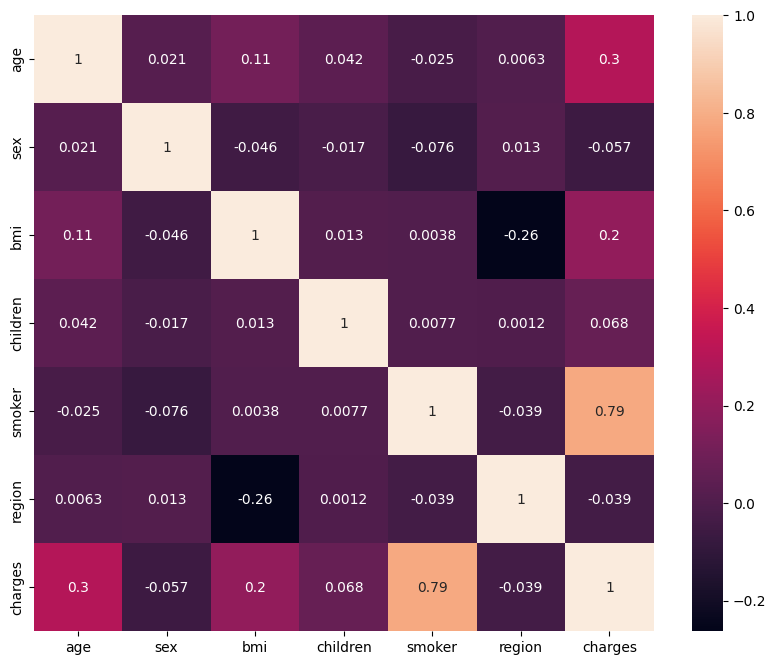

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)

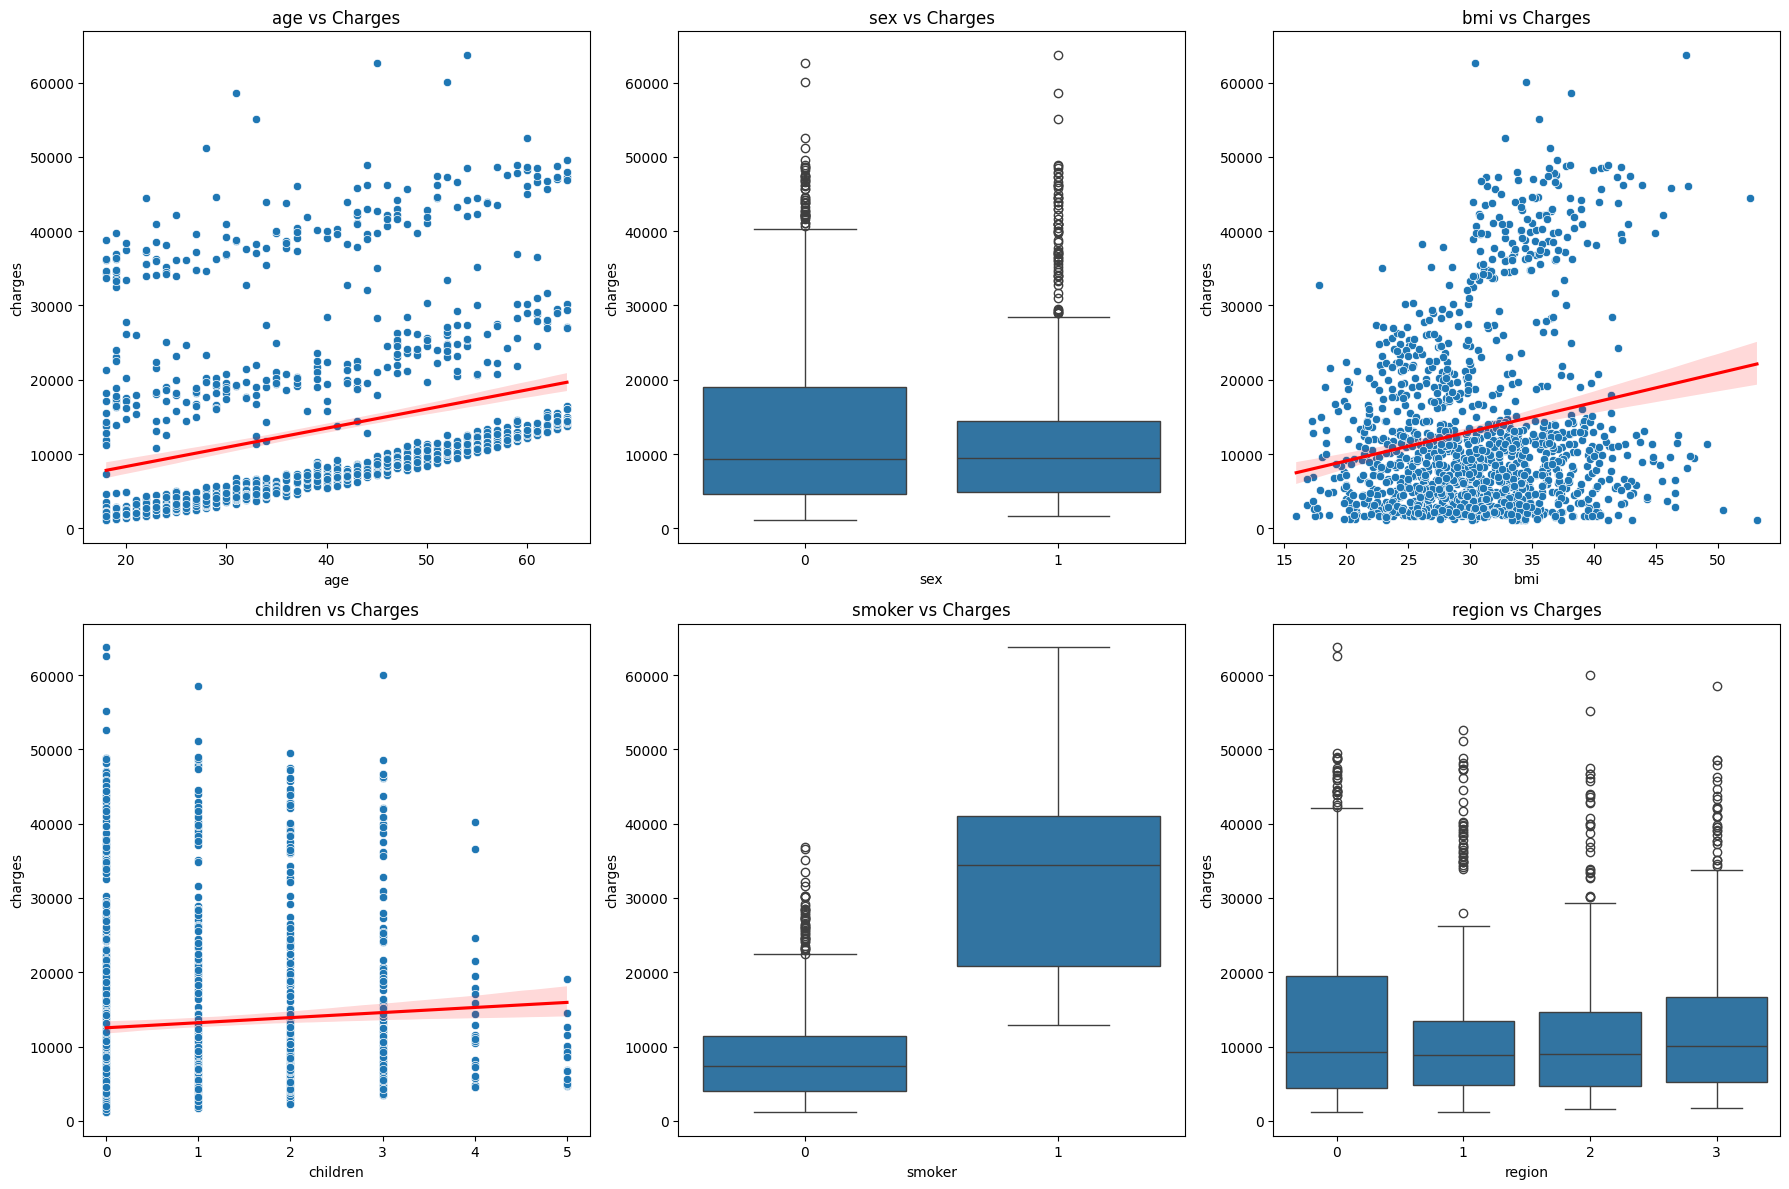

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

columns = ["age", "sex", "bmi", "children", "smoker", "region"]

plt.figure(figsize=(18,12))

for i, col in enumerate(columns):
    plt.subplot(2, 3, i+1)
    
    if col in ["sex", "smoker", "region"]:
        sns.boxplot(x=col, y="charges", data=df)
    else:
        sns.scatterplot(x=col, y="charges", data=df)
        sns.regplot(x=col, y="charges", data=df, scatter=False, color="red")
    
    plt.title(f"{col} vs Charges")

plt.tight_layout()
plt.show()

### Model Training & Testing

X ve Y değişkenlerini belirliyoruz.

In [17]:
x= df.drop(['charges'], axis=1)
y= df['charges']

Kategorik değişkenleri one-hot encoding ile sayısal hale getiriyoruz.

In [18]:
x=pd.get_dummies(x,drop_first=True)

Ve Linear Regressionla test etmeye başlıyoruz.

In [19]:
lr=LinearRegression()

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [21]:
model=lr.fit(x_train,y_train)

In [22]:
tahmin=model.predict(x_test)

In [23]:
r2_score(y_test,tahmin)

0.7839279776463969

In [24]:
mean_squared_error(y_test,tahmin)**.5 

5791.796559035807

In [25]:
karsilastirma=pd.DataFrame()

In [26]:
karsilastirma['gercek']=y_test
karsilastirma['tahmin']=tahmin

In [27]:
karsilastirma

,gercek,tahmin
764,9095.06825,8856.651536
887,5272.17580,7101.882358
890,29330.98315,36893.618988
1293,9301.89355,9470.364241
259,33750.29180,27035.848445
...,...,...
109,47055.53210,38918.765285
575,12222.89830,11780.420912
535,6067.12675,7584.912388
543,63770.42801,40806.644525


In [28]:
fi=pd.DataFrame({'Feature':x_train.columns,'Coef':model.coef_[0]})

In [29]:
fi

,Feature,Coef
0,age,256.600616
1,sex,256.600616
2,bmi,256.600616
3,children,256.600616
4,smoker,256.600616
5,region,256.600616


In [30]:
scaler=StandardScaler()

In [31]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

Birde Derin Öğrenme ile tekrardan test ediyoruz.

In [32]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(84, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(54, activation='relu'))
model.add(Dense(44, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(14, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [33]:
history = model.fit(x_train, y_train,validation_split=0.2,epochs=50,batch_size=32)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 325435328.0000 - mae: 13517.4219 - val_loss: 310183456.0000 - val_mae: 12648.9727
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 322894304.0000 - mae: 13434.9170 - val_loss: 300273792.0000 - val_mae: 12304.8555
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 257581712.0000 - mae: 11259.8711 - val_loss: 133304272.0000 - val_mae: 7077.3433
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 81668304.0000 - mae: 7018.5732 - val_loss: 59674444.0000 - val_mae: 5264.5171
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 48016028.0000 - mae: 5159.7700 - val_loss: 39690316.0000 - val_mae: 4629.9810
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 38364180.0000 - mae: 4291.6699 - val_loss: 35316228.0000 - val_mae: 4328.7314
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 35306416.0000 - mae: 4066.3577 - val_loss: 32622596.0000 - val_mae: 3934.7131
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━

In [34]:
model.save('predict_health_model.h5')

In [35]:
model.evaluate(x_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20267470.0000 - mae: 2503.3455


[20267470.0, 2503.345458984375]

In [36]:
y_pred = model.predict(x_test)
print("R2:", r2_score(y_test, y_pred))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
R2: 0.8694516103657707


In [37]:
history_df = pd.DataFrame(history.history)
history_df.head()

,loss,mae,val_loss,val_mae
0,325435328.0,13517.421875,310183456.0,12648.972656
1,322894304.0,13434.916992,300273792.0,12304.855469
2,257581712.0,11259.871094,133304272.0,7077.343262
3,81668304.0,7018.573242,59674444.0,5264.517090
4,48016028.0,5159.770020,39690316.0,4629.980957


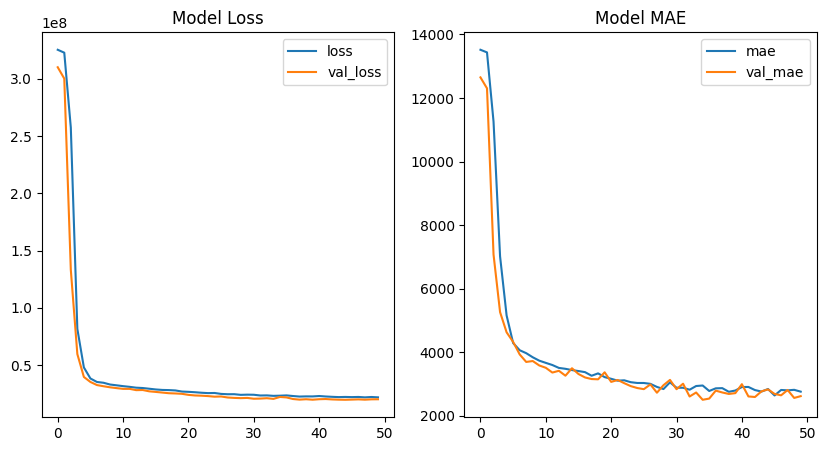

In [38]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(history_df['loss'], label='loss')
plt.plot(history_df['val_loss'], label='val_loss')
plt.title("Model Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_df['mae'], label='mae')
plt.plot(history_df['val_mae'], label='val_mae')
plt.title("Model MAE")
plt.legend()

plt.show()

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()

       
        
        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,kn,dt,xgb,svr,mlp_regressor]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','AdaBoost','Decision Tree','XGBRegressor','SVR','mlp_regressor']
        x=MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [40]:
algo_test(x,y)

,R_Squared,RMSE,MAE
Gradient Boosting,0.879037,4333.507975,2397.902189
XGBRegressor,0.856770,4715.541095,2644.708292
KNeighborsRegressor,0.851106,4807.871391,3656.543612
AdaBoost,0.787699,5741.032644,3600.272002
Linear,0.783928,5791.796559,4174.047876
Lasso,0.783865,5792.642310,4173.755208
Ridge,0.783518,5797.284728,4169.215125
SGD,0.782857,5806.131999,4125.642447
Extra Tree,0.721784,6572.116081,3115.163414
Decision Tree,0.718747,6607.889590,3239.251703


Model karşılaştırma sonuçlarına baktığımızda en iyi performansı Gradient Boosting ve XGBoost modelleri göstermiş.

Sonuç olarak, bu projede farklı makine öğrenmesi modelleri kullanılarak sağlık sigortası ücretleri tahmin edilmiştir. Yapılan karşılaştırmalar sonucunda en iyi performansı XGBoost modeli göstermiştir. Model, bireylerin yaş, BMI, sigara kullanımı ve diğer özelliklerine bakarak sigorta ücretlerini yüksek doğrulukla tahmin edebilmiştir. Bu tür çalışmalar sayesinde sigorta şirketleri risk analizi yapabilir, kullanıcılar ise maliyetlerini önceden öngörerek daha bilinçli kararlar alabilirler.


tesekkkürler :)